# freezing 8/24, regularization stuff, theres a somewehat useful script at the bottom

In [ ]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *

import copy
import time
import mat73
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from itertools import permutations, compress



%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
post=100
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'
h_list = pload('/home/diya/Documents/mp_opto/picklejar/h_list_10binsize_10lags_newlogspace.pickle')
session = MPOptoClass(session_path, post=post)

NameError: name 'pload' is not defined

# lets load several bits of data



In [3]:
pre = 100
binsize=10
nlags=10

laser_threshold = 2.26
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds = psth_bounds[np.array(session.laser['laser_powers']) > laser_threshold, :]
print(psth_bounds.shape)
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)

(17, 2)


In [1]:
(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCOb) = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=binsize, nlags=20)

NameError: name 'session' is not defined

In [5]:
CFA_lt, RFA_lt = session.binner(bounds=psth_bounds, fs=binsize, concat=True)
CFA_lt_PCA = CFA_PCObj.transform(CFA_lt)
RFA_lt_PCA = RFA_PCObj.transform(RFA_lt)
all_lt_PCA = np.hstack((CFA_lt_PCA, RFA_lt_PCA))
all_lt_PCA = unstitchSeams(all_lt_PCA, getSeamsFromBounds(bounds=psth_bounds, binsize=binsize))

all_laser_input, all_laser_true = format_and_stitch(all_lt_PCA, all_lt_PCA)
all_laser_input = all_laser_input[:-1, :]
all_laser_true = all_laser_true[1:,:]

CFA_clt, RFA_clt = session.binner(bounds=psth_ctrl_bounds, fs=binsize, concat=True)
CFA_clt_PCA = CFA_PCObj.transform(CFA_clt)
RFA_clt_PCA = RFA_PCObj.transform(RFA_clt)
all_clt_PCA = np.hstack((CFA_clt_PCA, RFA_clt_PCA))
all_clt_PCA = unstitchSeams(all_clt_PCA, getSeamsFromBounds(bounds=psth_ctrl_bounds, binsize=binsize))

all_c_laser_input, all_c_laser_true = format_and_stitch(all_clt_PCA, all_clt_PCA)
all_c_laser_input = all_c_laser_input[:-1, :]
all_c_laser_true = all_c_laser_true[1:,:]

# 1. what regularization weights for each model are we using

In [6]:
def weights_per_region(h, predic_var, num_CFA=91):
    CFA = np.sum(np.abs(h[1:num_CFA*10+1, num_CFA:]), axis=0)
    RFA = np.sum(np.abs(h[num_CFA*10+1:, num_CFA:]), axis=0)

    return np.average(CFA), np.average(RFA)

def relative_input(h, this_input, num_CFA=91):
    bias = h[0,num_CFA:]
    bias = bias[None, :]
    CFA_h = np.vstack((bias, h[1:num_CFA*10+1, num_CFA:]))
    RFA_h = np.vstack((bias, h[num_CFA*10+1:, num_CFA:]))

    CFA_drive = np.sum(np.abs(test_wiener_filter(this_input[:, :num_CFA*10], CFA_h)))
    RFA_drive = np.sum(np.abs(test_wiener_filter(this_input[:, num_CFA*10:], RFA_h)))

    return CFA_drive, RFA_drive


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


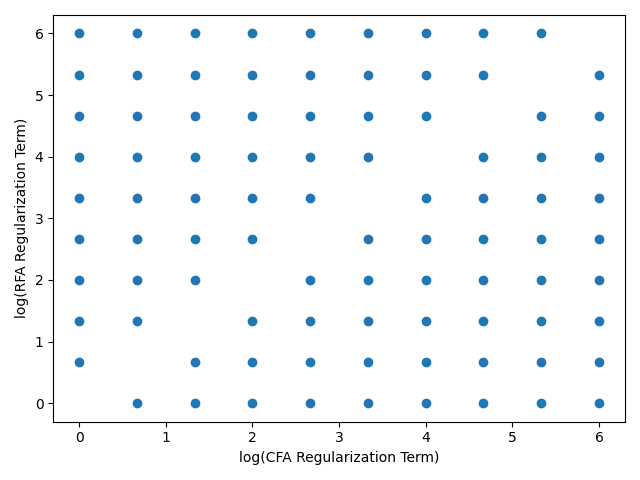

In [16]:
regs = np.logspace(0, 6, 10)
regs_permute = list(permutations(regs, 2))
X = np.log10(np.array(regs_permute)[:,0])
Y = np.log10(np.array(regs_permute)[:,1])

fig1, ax1 = plt.subplots()
ax1.scatter(X, Y)
ax1.set_ylabel('log(RFA Regularization Term)')
ax1.set_xlabel('log(CFA Regularization Term)')
fig1.tight_layout()

# 2. How well does each model fit on RFA data

In [8]:
h_fit_scores = []
h_fit_weights = []
h_fit_relinputs= []
for h in tqdm(h_list):
    y_pred = test_wiener_filter(all_nlags_PCA, h)
    predic_rfa_var = np.var(y_pred[:, session.num_CFA:], axis=0)
    temp1, temp2 = weights_per_region(h, predic_rfa_var)
    h_fit_weights.append([temp1, temp2])
    temp1, temp2 = relative_input(h, all_nlags_PCA)
    h_fit_relinputs.append([temp1, temp2])
    h_fit_scores.append(weighted_r2(all_cut_PCA[:, session.num_CFA:], y_pred[:, session.num_CFA:]))

100%|████████████████████████████████████████████████| 90/90 [02:53<00:00,  1.92s/it]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


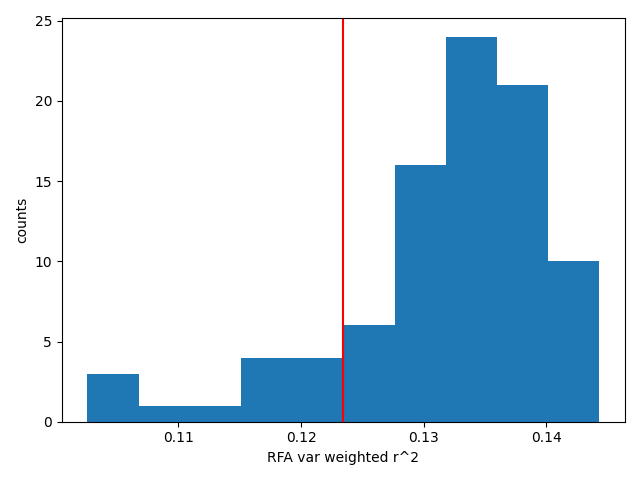

In [9]:
fig2, ax2 = plt.subplots()
nada, edges, nada = ax2.hist(h_fit_scores)
ax2.set_xlabel('RFA var weighted r^2')
ax2.set_ylabel('counts')
ax2.axvline(edges[5], color='red')
fig2.tight_layout()

In [10]:
good_h = list(compress(h_list, h_fit_scores > edges[5]))
good_h_regs = list(compress(regs_permute, h_fit_scores > edges[5]))
good_h_fit_scores = list(compress(h_fit_scores, h_fit_scores > edges[5]))
good_h_fit_weights = np.array(h_fit_weights)[h_fit_scores>edges[5],:]
good_h_fit_relinputs = np.array(h_fit_relinputs)[h_fit_scores>edges[5],:]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


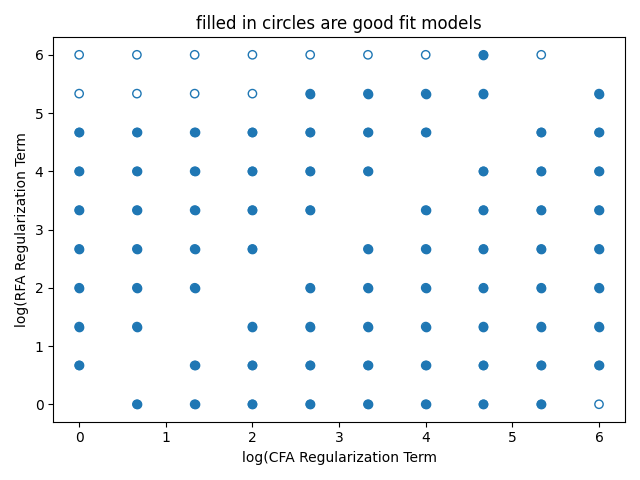

In [20]:
X_good = np.log10(np.array(good_h_regs)[:,0])
Y_good = np.log10(np.array(good_h_regs)[:,1])
fig21, ax21 = plt.subplots()
X = np.log10(np.array(regs_permute)[:,0])
Y = np.log10(np.array(regs_permute)[:,1])
ax21.scatter(X_good, Y_good)
ax21.scatter(X, Y, facecolors='none', edgecolor='tab:blue')
ax21.set_ylabel('log(RFA Regularization Term')
ax21.set_xlabel('log(CFA Regularization Term')
ax21.set_title('filled in circles are good fit models')
fig21.tight_layout()

In [12]:
h_laser_scores = []
h_laser_weights = []
h_laser_relinputs = []
for h in good_h:
    y_pred = test_wiener_filter(all_laser_input, h)
    predic_rfa_var = np.var(y_pred[:, session.num_CFA:], axis=0)
    temp1, temp2 = weights_per_region(h, predic_rfa_var)
    h_laser_weights.append([temp1, temp2])
    temp1, temp2 = relative_input(h, all_laser_input)
    h_laser_relinputs.append([temp1, temp2])
    h_laser_scores.append(weighted_r2(all_laser_true[:, session.num_CFA:], y_pred[:, session.num_CFA:]))
    
h_laser_weights = np.array(h_laser_weights)
h_laser_relinputs = np.array(h_laser_relinputs)

In [13]:
h_ctrl_scores = []
h_ctrl_weights = []
h_ctrl_relinputs = []
for h in good_h:
    y_pred = test_wiener_filter(all_c_laser_input, h)
    predic_rfa_var = np.var(y_pred[:, session.num_CFA:], axis=0)
    temp1, temp2 = weights_per_region(h, predic_rfa_var)
    h_ctrl_weights.append([temp1, temp2])
    temp1, temp2 = relative_input(h, all_c_laser_input)
    h_ctrl_relinputs.append([temp1, temp2])
    h_ctrl_scores.append(weighted_r2(all_c_laser_true[:, session.num_CFA:], y_pred[:, session.num_CFA:]))
    
h_ctrl_weights = np.array(h_ctrl_weights)
h_ctrl_relinputs = np.array(h_ctrl_relinputs)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


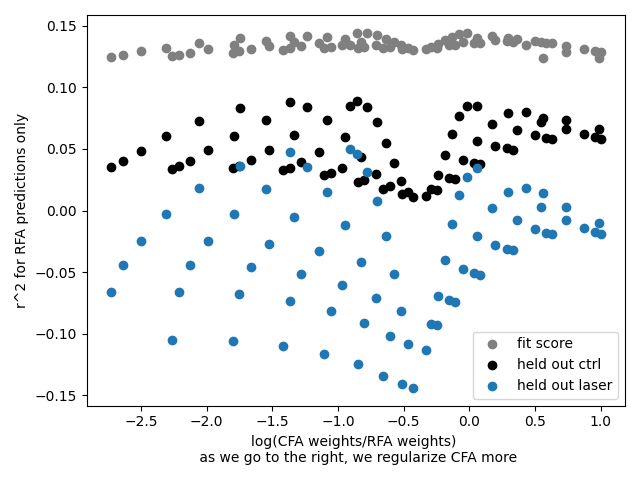

In [17]:
fit_ratio = good_h_fit_weights[:,0] / good_h_fit_weights[:,1]
laser_ratio = h_laser_weights[:,0] / h_laser_weights[:,1]
ctrl_ratio = h_ctrl_weights[:,0] / h_ctrl_weights[:,1]
fig2, ax2 = plt.subplots()
ax2.scatter(np.log10(fit_ratio), good_h_fit_scores, color='gray', label='fit score')
ax2.scatter(np.log10(laser_ratio), h_ctrl_scores, color='black', label='held out ctrl')
ax2.scatter(np.log10(ctrl_ratio), h_laser_scores, label='held out laser')
ax2.set_xlabel('log(CFA weights/RFA weights) \n as we go to the right, we regularize CFA more')
ax2.set_ylabel('r^2 for RFA predictions only')
ax2.legend()

fig2.tight_layout()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


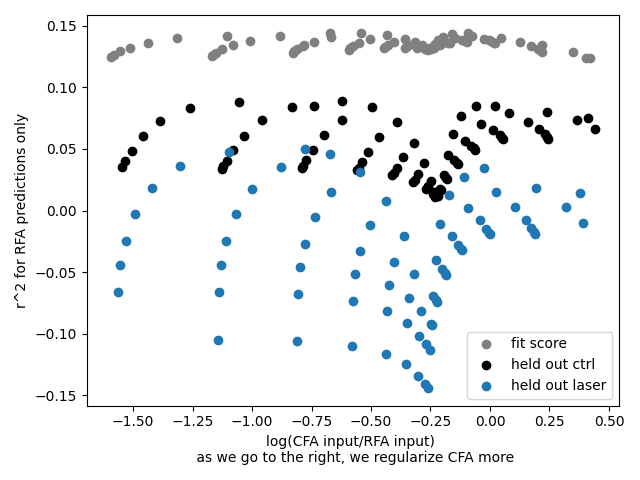

In [18]:
fit_ratio = good_h_fit_relinputs[:,0] / good_h_fit_relinputs[:,1]
laser_ratio = h_laser_relinputs[:,0] / h_laser_relinputs[:,1]
ctrl_ratio = h_ctrl_relinputs[:,0] / h_ctrl_relinputs[:,1]
fig3, ax3 = plt.subplots()
ax3.scatter(np.log10(fit_ratio), good_h_fit_scores, color='gray', label='fit score')
ax3.scatter(np.log10(laser_ratio), h_ctrl_scores, color='black', label='held out ctrl')
ax3.scatter(np.log10(ctrl_ratio), h_laser_scores, label='held out laser')
ax3.set_xlabel('log(CFA input/RFA input) \n as we go to the right, we regularize CFA more')
ax3.set_ylabel('r^2 for RFA predictions only')
ax3.legend()

fig3.tight_layout()

# 3. lets check CFA

In [107]:

num_RFA = 0-session.num_RFA
h_fit_scores = []
h_fit_weights = []
h_fit_relinputs= []
for h in tqdm(h_list):
    y_pred = test_wiener_filter(all_nlags_PCA, h)
    predic_rfa_var = np.var(y_pred[:, -session.num_RFA:], axis=0)
    temp1, temp2 = weights_per_region(h, predic_rfa_var, -session.num_RFA)
    h_fit_weights.append([temp1, temp2])
    temp1, temp2 = relative_input(h, all_nlags_PCA, -session.num_RFA)
    h_fit_relinputs.append([temp1, temp2])
    h_fit_scores.append(weighted_r2(all_cut_PCA[:, -session.num_RFA:], y_pred[:, -session.num_RFA:]))

  0%|                                                                 | 0/90 [00:00<?, ?it/s]


ValueError: shapes (55183,911) and (912,214) not aligned: 911 (dim 1) != 912 (dim 0)

In [213]:
h_fit_scores = []
for h in h_list:
    y_pred = test_wiener_filter(all_nlags_PCA, h)
    h_fit_scores.append(weighted_r2(all_cut_PCA[:, :session.num_CFA], y_pred[:, :session.num_CFA]))

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


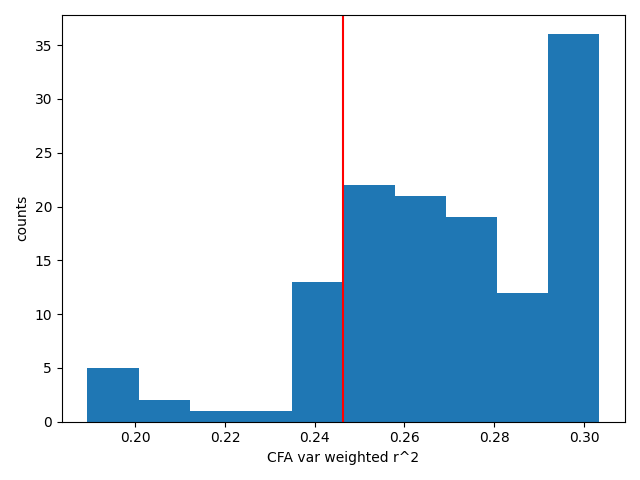

In [214]:
fig3, ax3 = plt.subplots()
nada, edges, nada = ax3.hist(h_fit_scores)
ax3.set_xlabel('CFA var weighted r^2')
ax3.set_ylabel('counts')
ax3.axvline(edges[5], color='red')
fig3.tight_layout()

In [222]:
good_h = list(compress(h_list, h_fit_scores > edges[5]))
good_h_weights = list(compress(weight_combos, h_fit_scores > edges[5]))
good_h_fit_scores = list(compress(h_fit_scores, h_fit_scores > edges[5]))

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


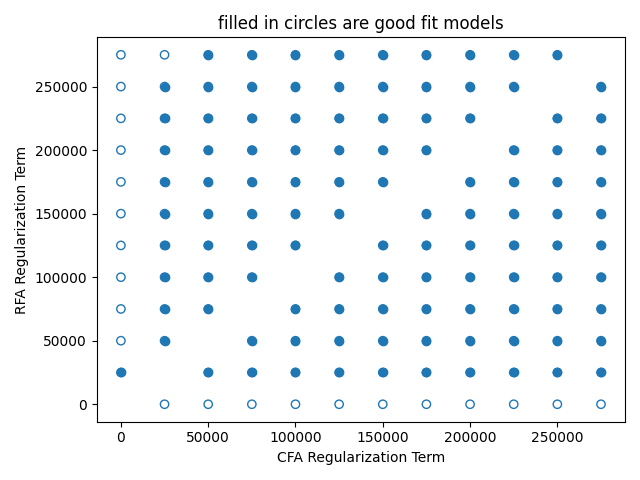

In [228]:
X_good = np.array(good_h_weights)[:,0]
Y_good = np.array(good_h_weights)[:,1]
fig30, ax30 = plt.subplots()
X = np.array(weight_combos)[:,0]
Y = np.array(weight_combos)[:,1]
ax30.scatter(X_good, Y_good)
ax30.scatter(X, Y, facecolors='none', edgecolor='tab:blue')
ax30.set_ylabel('RFA Regularization Term')
ax30.set_xlabel('CFA Regularization Term')
ax30.set_title('filled in circles are good fit models')
fig30.tight_layout()

In [229]:
h_laser_scores = []
for h in good_h:
    y_pred = test_wiener_filter(all_laser_input, h)
    h_laser_scores.append(weighted_r2(all_laser_true[:, :session.num_CFA], y_pred[:, :session.num_CFA]))

In [230]:
h_ctrl_scores = []
for h in good_h:
    y_pred = test_wiener_filter(all_c_laser_input, h)
    h_ctrl_scores.append(weighted_r2(all_c_laser_true[:, :session.num_CFA], y_pred[:, :session.num_CFA]))

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)
/tmp/ipykernel_127803/2802398616.py:3: RuntimeWarning: divide by zero encountered in log
  ax31.scatter(np.log(ratios), good_h_fit_scores, color='gray', label='fit score')
/tmp/ipykernel_127803/2802398616.py:4: RuntimeWarning: divide by zero encountered in log
  ax31.scatter(np.log(ratios), h_ctrl_scores, color='black', label='held out ctrl')
/tmp/ipykernel_127803/2802398616.py:5: RuntimeWarning: divide by zero encountered in log
  ax31.scatter(np.log(ratios), h_laser_scores, label='held out laser')


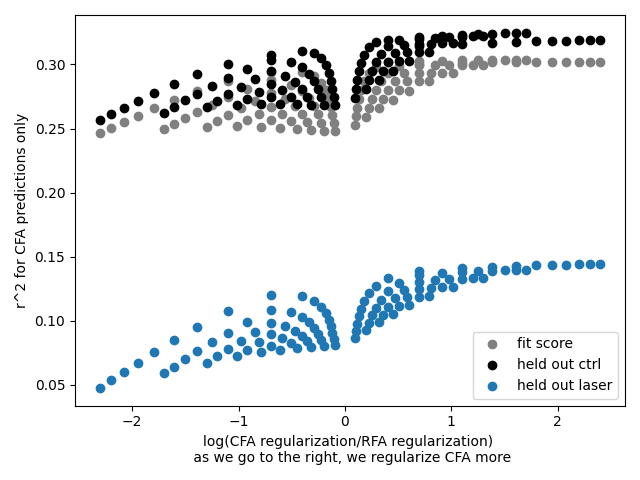

In [231]:
ratios = np.array(good_h_weights)[:,0] / np.array(good_h_weights)[:,1]
fig31, ax31 = plt.subplots()
ax31.scatter(np.log(ratios), good_h_fit_scores, color='gray', label='fit score')
ax31.scatter(np.log(ratios), h_ctrl_scores, color='black', label='held out ctrl')
ax31.scatter(np.log(ratios), h_laser_scores, label='held out laser')
ax31.set_xlabel('log(CFA regularization/RFA regularization) \n as we go to the right, we regularize CFA more')
ax31.set_ylabel('r^2 for CFA predictions only')
ax31.legend()

fig31.tight_layout()

# 4. Brief script to train our h_list ---- this is out of order, and is used above

In [16]:
weights = np.logspace(0, 6, 10)
weight_combos = list(permutations(weights, 2))

In [17]:
post=100
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'
h_list = pload('/home/diya/Documents/mp_opto/picklejar/h_list.pickle')
session = MPOptoClass(session_path, post=post)

love


In [18]:
pre = 100
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)

In [19]:
(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)

In [20]:
h_list = []
for weights in tqdm(weight_combos):
    C = np.zeros(all_nlags_PCA.shape[1] + 1)
    C[1:(session.num_CFA * 10)+1] = weights[0]
    C[(session.num_CFA * 10)+1:] = weights[1]
    
    h_list.append(train_wiener_filter(all_nlags_PCA, all_cut_PCA, C=C))
    time.sleep(20)
pdump(h_list, '/home/diya/Documents/mp_opto/picklejar/h_list_10binsize_10lags_logspace6.pickle')

  0%|                                                                  | 0/90 [00:00<?, ?it/s]

best_c: [0.         1.         1.         ... 4.64158883 4.64158883 4.64158883]
0.17


  1%|▋                                                         | 1/90 [00:28<42:07, 28.40s/it]

best_c: [ 0.         1.         1.        ... 21.5443469 21.5443469 21.5443469]
0.16


  2%|█▎                                                        | 2/90 [00:56<41:29, 28.30s/it]

...

 98%|███████████████████████████████████████████████████████▋ | 88/90 [41:19<00:56, 28.06s/it]

best_c: [      0.         1000000.         1000000.         ...   46415.88833613
   46415.88833613   46415.88833613]
0.08


 99%|████████████████████████████████████████████████████████▎| 89/90 [41:47<00:28, 28.07s/it]

best_c: [      0.         1000000.         1000000.         ...  215443.46900319
  215443.46900319  215443.46900319]
0.05


100%|█████████████████████████████████████████████████████████| 90/90 [42:15<00:00, 28.18s/it]


# NUMBERS FROM SCRIPTS I'VE RAN OUTSIDE

best regulartion CFA: best_c: 33199.88888888889
best regularization RFA: best_c: 180000.0